# Demonstration of MUSE working on three modalities

This is a demonstration of MUSE analysis on simulated data with three modalities.

Feng Bao @ Altschuler & Wu Lab @ UCSF 2022.

Software provided as is under MIT License.

## Import packages

In [9]:
import muse_sc_3_modalities as muse
import simulation_tool.multi_modal_simulation as simulation
import phenograph
from sklearn.decomposition import PCA
import numpy as np
from sklearn.metrics.cluster import adjusted_rand_score
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import tensorflow as tf
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel('ERROR')

np.random.seed(0)

## Generate simulation data


Simulation parameters

In [10]:
latent_dim = 100
num_cluster = 10
sample_size = 1000
latent_code_dim = 30
observed_data_dim = 500
sigma_1 = 0.1
sigma_2 = 0.1
sigma_3 = 0.1
decay_coef_1 = 0.5
decay_coef_2 = 0.1
decay_coef_3 = 0.1
merge_prob = 0.7



Use simulation tool to generate multi-modality data

In [ ]:
data = simulation.multi_modal_simulator_3_modalities(
    num_cluster,
    sample_size,
    observed_data_dim,
    observed_data_dim,
    observed_data_dim,
    latent_code_dim,
    sigma_1,
    sigma_2,
    sigma_3,
    decay_coef_1,
    decay_coef_2,
    decay_coef_3,
    merge_prob,
)
data_a = data["data_a_dropout"]
data_b = data["data_b_dropout"]
data_c = data["data_c_dropout"]
label_a = data["data_a_label"]
label_b = data["data_b_label"]
label_c = data["data_c_label"]
label_true = data["true_cluster"]

## Analyses based on single modality

Learn features from single modality

In [12]:
view_a_feature = PCA(n_components=latent_dim).fit_transform(data_a)
view_b_feature = PCA(n_components=latent_dim).fit_transform(data_b)
view_c_feature = PCA(n_components=latent_dim).fit_transform(data_c)

Perform clustering using PhenoGraph

In [13]:
view_a_label, _, _ = phenograph.cluster(view_a_feature)
view_b_label, _, _ = phenograph.cluster(view_b_feature)
view_c_label, _, _ = phenograph.cluster(view_c_feature)

Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.0328676700592041 seconds
Jaccard graph constructed in 0.2753787040710449 seconds
Wrote graph to binary file in 0.005746126174926758 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.566082
Louvain completed 21 runs in 0.6126399040222168 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 1.1585345268249512 seconds
Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.07287287712097168 seconds
Jaccard graph constructed in 0.2793581485748291 seconds
Wrote graph to binary file in 0.0050809383392333984 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.676441
Louvain completed 21 runs in 0.6212232112884521 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 1.2189550399780273 seconds
Finding 30 nearest neighbors using minkows

## Combined analysis using MUSE

MUSE learns the joint latent representation

In [14]:
muse_feature, reconstruct_x, reconstruct_y, reconstruct_z, latent_x, latent_y, latent_z = muse.muse_fit_predict(
    data_a, data_b, data_c, view_a_label, view_b_label, view_c_label
)

++++++++++ MUSE for multi-modality single-cell analysis ++++++++++
MUSE initialization
epoch: 0, 	 total loss: 2708.62524,	 reconstruction loss: 1200.66138,	 sparse penalty: 301.59277
epoch: 50, 	 total loss: 1736.54968,	 reconstruction loss: 311.01697,	 sparse penalty: 285.10654
epoch: 100, 	 total loss: 1652.68726,	 reconstruction loss: 310.71014,	 sparse penalty: 268.39542
epoch: 150, 	 total loss: 1570.08459,	 reconstruction loss: 309.54688,	 sparse penalty: 252.10754
epoch: 0, 	 total loss: 1511.98071,	 reconstruction loss: 306.65198,	 sparse penalty: 236.36234,	 x triplet: 1.49110,	 y triplet: 1.64833,	 z triplet: 1.56398
epoch: 50, 	 total loss: 1434.28992,	 reconstruction loss: 303.30701,	 sparse penalty: 221.21542,	 x triplet: 1.83014,	 y triplet: 1.65946,	 z triplet: 1.49155
epoch: 100, 	 total loss: 1357.55505,	 reconstruction loss: 299.17804,	 sparse penalty: 206.67792,	 x triplet: 1.86781,	 y triplet: 1.65829,	 z triplet: 1.47135
epoch: 150, 	 total loss: 1283.44995,	 reco

## Perform clustering
PhenoGraph clustering

In [15]:
muse_label, _, _ = phenograph.cluster(muse_feature)

Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.07057023048400879 seconds
Jaccard graph constructed in 0.29199934005737305 seconds
Wrote graph to binary file in 0.0041615962982177734 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.897496
Louvain completed 21 runs in 0.6486284732818604 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 1.2654948234558105 seconds


## Visualization of latent spaces 
Latent spaces of single-modality features or MUSE features were visualized using tSNE, with ground truth cluster labels.

Cluster accuries were quantified using adjusted Rand index (ARI). ARI = 1 indicates perfectly discover true cell identities.

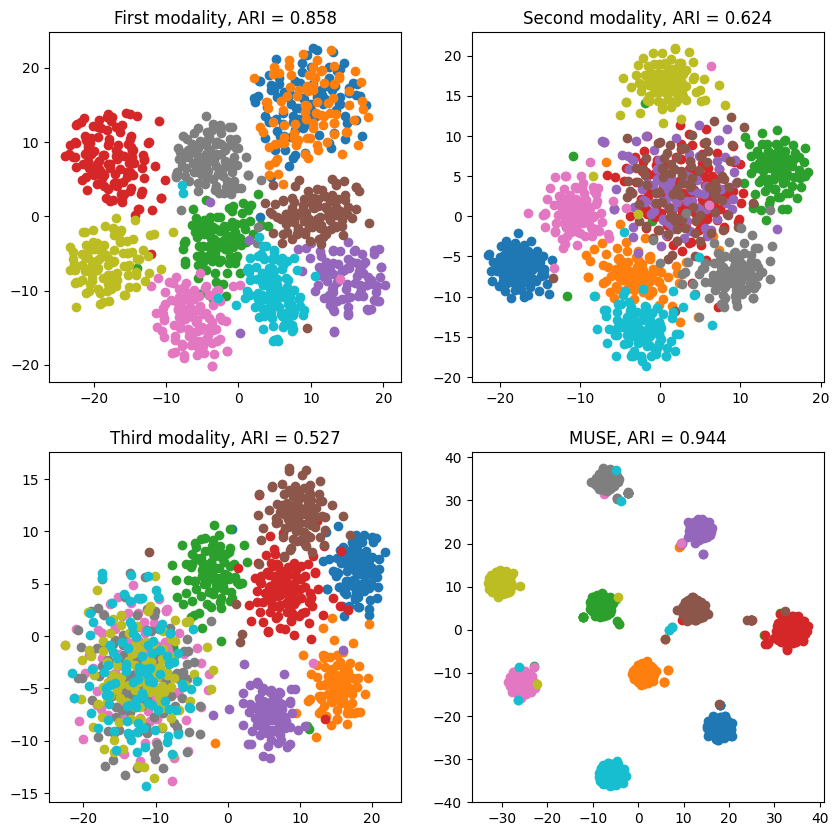

In [16]:
plt.figure(figsize=(10, 10))
plt.subplot(2, 2, 1)
X_embedded = TSNE(n_components=2).fit_transform(view_a_feature)
for i in np.unique(label_true):
    idx = np.nonzero(label_true == i)[0]
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1])
    plt.title('First modality, ARI = %01.3f' % adjusted_rand_score(label_true, view_a_label))

plt.subplot(2, 2, 2)
X_embedded = TSNE(n_components=2).fit_transform(view_b_feature)
for i in np.unique(label_true):
    idx = np.nonzero(label_true == i)[0]
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1])
    plt.title('Second modality, ARI = %01.3f' % adjusted_rand_score(label_true, view_b_label))

plt.subplot(2, 2, 3)
X_embedded = TSNE(n_components=2).fit_transform(view_c_feature)
for i in np.unique(label_true):
    idx = np.nonzero(label_true == i)[0]
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1])
    plt.title('Third modality, ARI = %01.3f' % adjusted_rand_score(label_true, view_c_label))

plt.subplot(2, 2, 4)
X_embedded = TSNE(n_components=2).fit_transform(muse_feature)
for i in np.unique(label_true):
    idx = np.nonzero(label_true == i)[0]
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1])
    plt.title('MUSE, ARI = %01.3f' % adjusted_rand_score(label_true, muse_label))